In [1]:
from itertools import permutations
import time
import math
import numpy as np

def time_func(func):
    def wrapper(*args, **kwargs):
        start_time = time.time()
        result = func(*args, **kwargs)
        end_time = time.time()
        elapsed_time = end_time - start_time
        print(f"Function '{func.__name__}' took {elapsed_time:.6f} seconds to execute")
        return result
    return wrapper

def generate_distance_matrix(n):
    if n <= 0:
        raise ValueError("Number 'n' must be greater than 0.")

    # Create a random symmetric matrix with distances between 1 and 100
    distances = np.random.randint(1, 101, size=(n, n))
    distances_symmetric = (distances + distances.T) // 2  # Make the matrix symmetric

    # Set diagonal elements to 0 (distance from a node to itself)
    np.fill_diagonal(distances_symmetric, 0)

    return distances_symmetric

def calculate_total_distance(order, distances):
    total_distance = 0
    for i in range(len(order) - 1):
        total_distance += distances[order[i]][order[i + 1]]
    total_distance += distances[order[-1]][order[0]]  # Return to the starting city
    return total_distance


@time_func
def brute_force_tsp(distances, display_solutions=True, display_results=True):
    
    cities = [chr(ord('A') + i) for i in range(len(distances[0]))] # get list of cities name as letters.
    
    print(f'For {len(cities)} cities, departing and arriving from A, there are {math.factorial(len(cities)-1)} possible paths.')
    
    all_permutations = permutations(range(1,len(distances)))
    
    min_distance = float('inf')
    optimal_route = None
    
    i = 0
    for perm in all_permutations:
        perm = [0] + [i for i in perm]
        total_distance = calculate_total_distance(perm, distances)
        if total_distance < min_distance:
            min_distance = total_distance
            optimal_route = perm

        if display_solutions:
            print('-'.join([cities[i] for i in perm]), ', Distance: ', total_distance)

        i +=1
    
    if display_results:
        # Print the result
        print('Total number of paths:', i)
        print("Optimal Route:", [cities[i] for i in optimal_route])
        print("Minimum Distance:", min_distance)

    return optimal_route, min_distance



In [2]:


# City names

# Example distances (replace with your distances)
# Each element of the matrix is the distance from one city to another one. 
# For example, the distance from city A to B is equal to 5, so you can see the
# number 5 both in the matrix elements AB and BA. This is because it is a 
# simetry TSP example. To make an asymmetrical TSP problem, use different values
# for matrix elements AB and BA, which mean different distances depending on the direction. 
#
# matrix_example = [
#       A  B  C  D  E
#    A [0, 5, 3, 7, 4],
#    B [5, 0, 2, 6, 8],
#    C [3, 2, 0, 2, 2],
#    D [7, 6, 2, 0, 3],
#    E [4, 8, 2, 3, 0]
# ]
# To add more vertices, only add more elements to the matrix. 
# Make sure the main diagonal is zero and a square matrix. 



distances = [
    [0, 5, 3, 7, 4],
    [5, 0, 2, 6, 8],
    [3, 2, 0, 2, 2],
    [7, 6, 2, 0, 3],
    [4, 8, 2, 3, 0],
]

# Solve TSP
optimal_route, min_distance = brute_force_tsp(distances)


For 5 cities, departing and arriving from A, there are 24 possible paths.
A-B-C-D-E , Distance:  16
A-B-C-E-D , Distance:  19
A-B-D-C-E , Distance:  19
A-B-D-E-C , Distance:  19
A-B-E-C-D , Distance:  24
A-B-E-D-C , Distance:  21
A-C-B-D-E , Distance:  18
A-C-B-E-D , Distance:  23
A-C-D-B-E , Distance:  23
A-C-D-E-B , Distance:  21
A-C-E-B-D , Distance:  26
A-C-E-D-B , Distance:  19
A-D-B-C-E , Distance:  21
A-D-B-E-C , Distance:  26
A-D-C-B-E , Distance:  23
A-D-C-E-B , Distance:  24
A-D-E-B-C , Distance:  23
A-D-E-C-B , Distance:  19
A-E-B-C-D , Distance:  23
A-E-B-D-C , Distance:  23
A-E-C-B-D , Distance:  21
A-E-C-D-B , Distance:  19
A-E-D-B-C , Distance:  18
A-E-D-C-B , Distance:  16
Total number of paths: 24
Optimal Route: ['A', 'B', 'C', 'D', 'E']
Minimum Distance: 16
Function 'brute_force_tsp' took 0.000403 seconds to execute


In [3]:
distances = [
    [0, 5, 3, 7, 4, 5],
    [5, 0, 2, 6, 8, 2],
    [3, 2, 0, 2, 2, 2],
    [7, 6, 2, 0, 3, 13],
    [4, 8, 2, 3, 0, 6],
    [5, 2, 2, 13, 6, 0]
    
]

# Solve TSP
optimal_route, min_distance = brute_force_tsp(distances)




For 6 cities, departing and arriving from A, there are 120 possible paths.
A-B-C-D-E-F , Distance:  23
A-B-C-D-F-E , Distance:  32
A-B-C-E-D-F , Distance:  30
A-B-C-E-F-D , Distance:  35
A-B-C-F-D-E , Distance:  29
A-B-C-F-E-D , Distance:  25
A-B-D-C-E-F , Distance:  26
A-B-D-C-F-E , Distance:  25
A-B-D-E-C-F , Distance:  23
A-B-D-E-F-C , Distance:  25
A-B-D-F-C-E , Distance:  32
A-B-D-F-E-C , Distance:  35
A-B-E-C-D-F , Distance:  35
A-B-E-C-F-D , Distance:  37
A-B-E-D-C-F , Distance:  25
A-B-E-D-F-C , Distance:  34
A-B-E-F-C-D , Distance:  30
A-B-E-F-D-C , Distance:  37
A-B-F-C-D-E , Distance:  18
A-B-F-C-E-D , Distance:  21
A-B-F-D-C-E , Distance:  28
A-B-F-D-E-C , Distance:  28
A-B-F-E-C-D , Distance:  24
A-B-F-E-D-C , Distance:  21
A-C-B-D-E-F , Distance:  25
A-C-B-D-F-E , Distance:  34
A-C-B-E-D-F , Distance:  34
A-C-B-E-F-D , Distance:  39
A-C-B-F-D-E , Distance:  27
A-C-B-F-E-D , Distance:  23
A-C-D-B-E-F , Distance:  30
A-C-D-B-F-E , Distance:  23
A-C-D-E-B-F , Distance:  23
A

In [4]:

# Use the funcion generate_distance_matrix to create a random distance matrix 
# of integer distances between 0 to 100 for n cities. 

n = 7
distances = generate_distance_matrix(n)
print(distances)

# Solve TSP
optimal_route, min_distance = brute_force_tsp(distances)




[[ 0 41 21 44 81 92 31]
 [41  0 53 61 58 87 51]
 [21 53  0 75 29 60 56]
 [44 61 75  0 39 23 52]
 [81 58 29 39  0 47 48]
 [92 87 60 23 47  0 67]
 [31 51 56 52 48 67  0]]
For 7 cities, departing and arriving from A, there are 720 possible paths.
A-B-C-D-E-F-G , Distance:  353
A-B-C-D-E-G-F , Distance:  415
A-B-C-D-F-E-G , Distance:  318
A-B-C-D-F-G-E , Distance:  388
A-B-C-D-G-E-F , Distance:  408
A-B-C-D-G-F-E , Distance:  416
A-B-C-E-D-F-G , Distance:  283
A-B-C-E-D-G-F , Distance:  373
A-B-C-E-F-D-G , Distance:  276
A-B-C-E-F-G-D , Distance:  333
A-B-C-E-G-D-F , Distance:  338
A-B-C-E-G-F-D , Distance:  305
A-B-C-F-D-E-G , Distance:  295
A-B-C-F-D-G-E , Distance:  358
A-B-C-F-E-D-G , Distance:  323
A-B-C-F-E-G-D , Distance:  345
A-B-C-F-G-D-E , Distance:  393
A-B-C-F-G-E-D , Distance:  352
A-B-C-G-D-E-F , Distance:  380
A-B-C-G-D-F-E , Distance:  353
A-B-C-G-E-D-F , Distance:  352
A-B-C-G-E-F-D , Distance:  312
A-B-C-G-F-D-E , Distance:  360
A-B-C-G-F-E-D , Distance:  347
A-B-D-C-E-F-

In [5]:
n = 10
distances = generate_distance_matrix(n)
print(distances)
print()

# Solve TSP
optimal_route, min_distance = brute_force_tsp(distances, display_solutions=False)




[[ 0 37 69 76 53 16 41 84 33 81]
 [37  0 54 37 42 53 16 32 63 69]
 [69 54  0 30 93 41 80 85 78 37]
 [76 37 30  0 76 52 46 48 10 10]
 [53 42 93 76  0 82 75 56 43 26]
 [16 53 41 52 82  0 88 24 27 53]
 [41 16 80 46 75 88  0 57 80 48]
 [84 32 85 48 56 24 57  0 29 64]
 [33 63 78 10 43 27 80 29  0 35]
 [81 69 37 10 26 53 48 64 35  0]]

For 10 cities, departing and arriving from A, there are 362880 possible paths.
Total number of paths: 362880
Optimal Route: ['A', 'F', 'H', 'I', 'D', 'C', 'J', 'E', 'B', 'G']
Minimum Distance: 271
Function 'brute_force_tsp' took 0.567538 seconds to execute


In [6]:
n = 11
distances = generate_distance_matrix(n)
print(distances)
print()
# Solve TSP
optimal_route, min_distance = brute_force_tsp(distances, display_solutions=False)




[[ 0 73 11 64 70 21 30 27 45 68 57]
 [73  0 58 49 75 31 53 16 33 41 76]
 [11 58  0 38 62 54 24 16 47 36 40]
 [64 49 38  0  9 63 16 54 44 32 66]
 [70 75 62  9  0 69 57 52 44 60 26]
 [21 31 54 63 69  0 54 64 30 23 89]
 [30 53 24 16 57 54  0 38 43 83 42]
 [27 16 16 54 52 64 38  0 43 57 44]
 [45 33 47 44 44 30 43 43  0 19 69]
 [68 41 36 32 60 23 83 57 19  0 77]
 [57 76 40 66 26 89 42 44 69 77  0]]

For 11 cities, departing and arriving from A, there are 3628800 possible paths.
Total number of paths: 3628800
Optimal Route: ['A', 'C', 'G', 'D', 'E', 'K', 'H', 'B', 'I', 'J', 'F']
Minimum Distance: 242
Function 'brute_force_tsp' took 6.007316 seconds to execute


For 2 cities, departing and arriving from A, there are 1 possible paths.
Function 'brute_force_tsp' took 0.000086 seconds to execute
For 3 cities, departing and arriving from A, there are 2 possible paths.
Function 'brute_force_tsp' took 0.000022 seconds to execute
For 4 cities, departing and arriving from A, there are 6 possible paths.
Function 'brute_force_tsp' took 0.000021 seconds to execute
For 5 cities, departing and arriving from A, there are 24 possible paths.
Function 'brute_force_tsp' took 0.000039 seconds to execute
For 6 cities, departing and arriving from A, there are 120 possible paths.
Function 'brute_force_tsp' took 0.000140 seconds to execute
For 7 cities, departing and arriving from A, there are 720 possible paths.
Function 'brute_force_tsp' took 0.000829 seconds to execute
For 8 cities, departing and arriving from A, there are 5040 possible paths.
Function 'brute_force_tsp' took 0.006658 seconds to execute
For 9 cities, departing and arriving from A, there are 40320 

Text(0.5, 0, 'número de cidades')

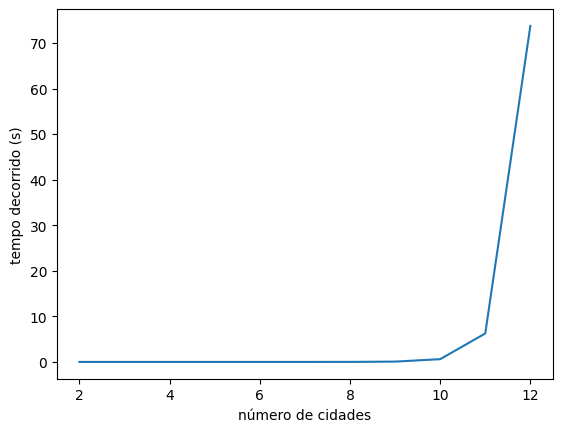

In [8]:
times = []
n = list(range(2,13))
for i in n:
    distances = generate_distance_matrix(i)
    
    start_time = time.time()

    optimal_route, min_distance = brute_force_tsp(distances, display_solutions=False, display_results=False)
    
    end_time = time.time()
    elapsed_time = end_time - start_time
    times.append(elapsed_time)

print(times)
import matplotlib.pyplot as plt

plt.plot(n, times)
plt.ylabel('tempo decorrido (s)')
plt.xlabel('número de cidades')